# The Physical Basis for Ocean Color Products

## Motivation

Ocean color remote sensing uses visible and near-infrared measurements to infer properties of the upper ocean. The most common product is **chlorophyll-a concentration**, which is often used as an indicator of phytoplankton biomass.

Ocean color observations are useful because phytoplankton form the base of many marine food webs and play an important role in the global carbon cycle. However, ocean color products require careful interpretation: a satellite does not directly measure chlorophyll-a. Instead, it measures radiance leaving the ocean-atmosphere system, and algorithms are used to convert those observations into geophysical products.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Key Questions

- What happens to sunlight when it reaches the ocean surface?
- How do absorption and scattering determine the color of the ocean?
- Why is chlorophyll-a visible to satellites?
- What are the main limitations of ocean color observations?

## Electromagnetic Radiation at the Ocean Surface

Visible light can penetrate the ocean surface. Once it reaches the ocean, several things can happen:

1. Some light is **directly reflected** from the surface.
2. Some light is **transmitted** into the water column.
3. Within the water column, light can be **absorbed** or **scattered**.
4. A small fraction of scattered light exits the ocean and travels upward toward the satellite.

The upward signal that exits the ocean is called **water-leaving radiance**. Ocean color algorithms are designed to isolate this water-leaving signal from other contributions such as atmospheric scattering, surface reflection, and sunglint.

## Absorption by Water

Liquid water absorbs long visible wavelengths more strongly than short visible wavelengths. Red light is absorbed efficiently, while blue light penetrates farther into clear water. Infrared radiation is absorbed extremely close to the surface, which is why infrared observations are useful for sea surface temperature but not for observing subsurface ocean color.

The figure below uses a simple synthetic curve to illustrate the qualitative pattern of pure-water absorption. It is not intended to replace a calibrated absorption table.

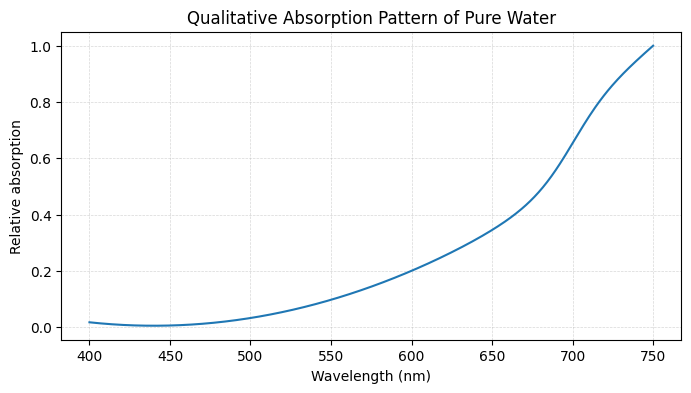

In [2]:
wavelength = np.linspace(400, 750, 400)  # nm

# Synthetic pure water absorption curve: low in blue, increasing toward red/NIR
water_absorption = 0.015 + 0.00002*(wavelength - 440)**2
water_absorption += 0.7 / (1 + np.exp(-(wavelength - 700)/12))
water_absorption = water_absorption / water_absorption.max()

plt.figure(figsize=(8,4))
plt.plot(wavelength, water_absorption)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Relative absorption')
plt.title('Qualitative Absorption Pattern of Pure Water')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.show()

## Absorption and Scattering

The color observed by a satellite depends on both **absorption** and **scattering**.

- **Absorption** removes photons from the light field and converts their energy to other forms, such as heat or chemical energy.
- **Scattering** redirects photons. Some scattered photons eventually leave the ocean and can be observed by a satellite.

In clear open-ocean water, blue wavelengths are scattered and transmitted efficiently, making the ocean appear blue. When phytoplankton, sediment, or colored dissolved organic matter are present, they change the shape of the spectrum of water-leaving radiance.

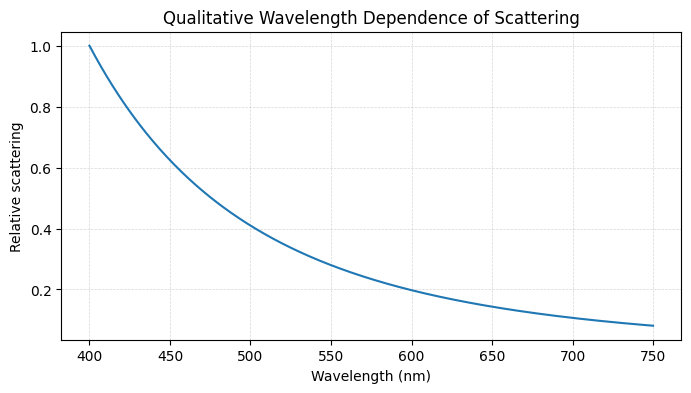

In [3]:
# Simple conceptual scattering curve: shorter wavelengths scatter more efficiently
scattering = (wavelength / 400) ** -4
scattering = scattering / scattering.max()

plt.figure(figsize=(8,4))
plt.plot(wavelength, scattering)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Relative scattering')
plt.title('Qualitative Wavelength Dependence of Scattering')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.show()

## Sunglint and Surface Reflection

Sunglint occurs when sunlight reflects off the ocean surface toward the satellite sensor. Glint can overwhelm the water-leaving radiance signal, especially when the Sun-sensor geometry is unfavorable or the ocean surface is rough.

Because ocean color retrievals rely on a small signal leaving the water column, sunglint and clouds are commonly masked from higher-level ocean color products.

## Phytoplankton and Chlorophyll-a

Phytoplankton are drifting photosynthetic organisms. All phytoplankton contain **chlorophyll-a**, a pigment used in photosynthesis. Chlorophyll-a absorbs strongly in the blue part of the visible spectrum and reflects or scatters more green light.

As chlorophyll-a concentration increases, the dominant color of water-leaving radiance shifts from blue toward green. This shift is the basis for many empirical satellite chlorophyll-a algorithms.

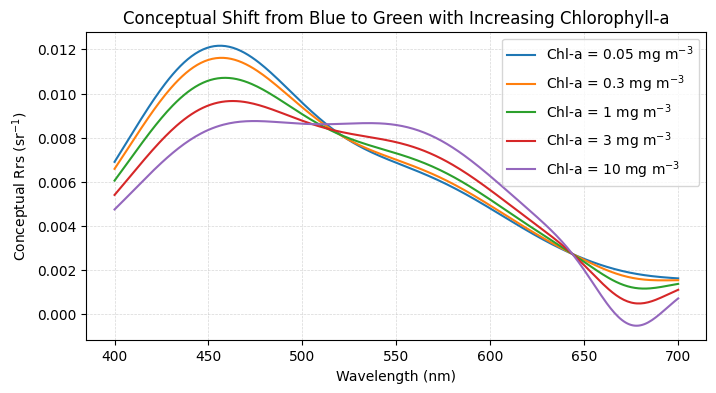

In [4]:
# Synthetic reflectance spectra for different chlorophyll levels
wl = np.linspace(400, 700, 301)

def synthetic_rrs(chl):
    """Conceptual remote-sensing reflectance spectrum for teaching."""
    blue_peak = 0.010 * np.exp(-0.5*((wl - 450)/45)**2) / (1 + 0.7*np.log10(chl + 1))
    green_peak = 0.0045 * np.exp(-0.5*((wl - 555)/55)**2) * (1 + 0.45*np.log10(chl + 1))
    red_absorption = 0.0025 * np.exp(-0.5*((wl - 675)/18)**2) * np.log10(chl + 1)
    baseline = 0.0015
    return baseline + blue_peak + green_peak - red_absorption

plt.figure(figsize=(8,4))
for chl in [0.05, 0.3, 1, 3, 10]:
    plt.plot(wl, synthetic_rrs(chl), label=f'Chl-a = {chl:g} mg m$^{{-3}}$')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Conceptual Rrs (sr$^{-1}$)')
plt.title('Conceptual Shift from Blue to Green with Increasing Chlorophyll-a')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.show()

## CDOM and Turbidity

Ocean color is not controlled by chlorophyll-a alone. Two other important constituents are:

- **CDOM:** colored dissolved organic matter, often associated with decaying biological material.
- **Suspended sediments:** particles that increase turbidity and scattering.

CDOM absorption can resemble chlorophyll-a absorption in the blue part of the spectrum, but CDOM lacks the additional chlorophyll-a absorption feature near 680 nm. This makes spectral information important for separating different water-column constituents.

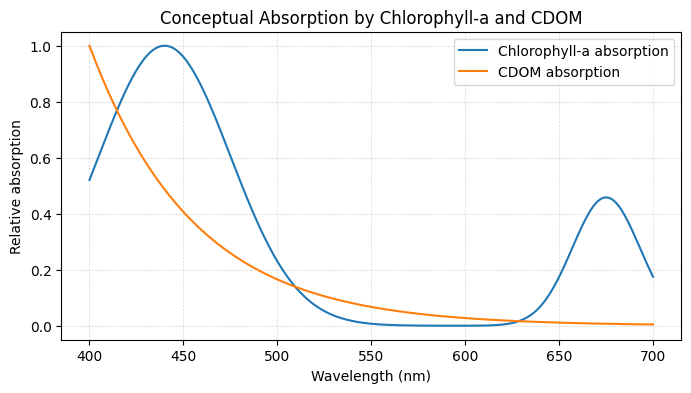

In [5]:
chl_abs = 1.2*np.exp(-0.5*((wl-440)/35)**2) + 0.55*np.exp(-0.5*((wl-675)/18)**2)
cdom_abs = np.exp(-0.018*(wl-400))
chl_abs = chl_abs / chl_abs.max()
cdom_abs = cdom_abs / cdom_abs.max()

plt.figure(figsize=(8,4))
plt.plot(wl, chl_abs, label='Chlorophyll-a absorption')
plt.plot(wl, cdom_abs, label='CDOM absorption')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Relative absorption')
plt.title('Conceptual Absorption by Chlorophyll-a and CDOM')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.show()

### Check Your Understanding

1. Why does clear open-ocean water often appear blue?
2. Why does high chlorophyll-a concentration tend to make water appear greener?
3. Why does sunglint need to be masked from ocean color products?
4. Why can CDOM complicate chlorophyll-a retrievals?

## Interpreting Chlorophyll-a Carefully

Chlorophyll-a is not the same thing as primary productivity. Chlorophyll-a gives information about phytoplankton biomass or pigment concentration, while productivity describes rates of carbon fixation.

For example, two regions may have similar chlorophyll-a concentrations but different productivity if light, nutrients, temperature, or grazing rates differ. Zooplankton grazing can also remove phytoplankton as quickly as they grow, masking changes in production when looking only at chlorophyll-a.

## Gross and Net Primary Productivity

- **Gross Primary Productivity (GPP):** total rate of organic carbon production through photosynthesis.
- **Respiration:** conversion of organic carbon back to inorganic carbon by autotrophs and other organisms.
- **Net Primary Productivity (NPP):** net rate of carbon fixation after accounting for autotrophic respiration.

Ocean color products can help estimate productivity, but chlorophyll-a alone is not enough. Productivity algorithms usually require additional information such as light availability, temperature, mixed-layer depth, and assumptions about phytoplankton physiology.

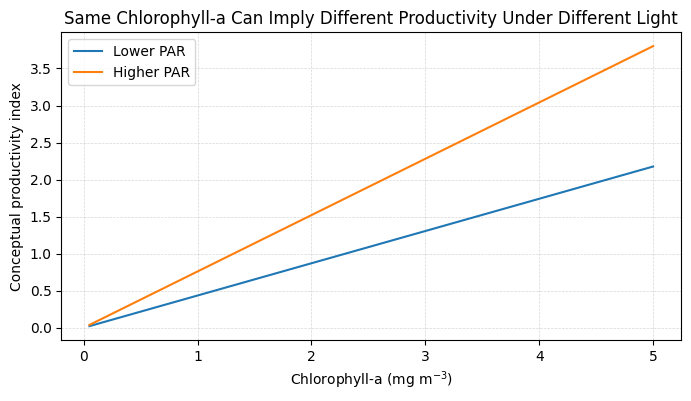

In [12]:
# Conceptual productivity example
chl = np.linspace(0.05, 5, 100)
par_low = 20
par_high = 50

# A simple saturating productivity index for teaching
prod_low_light = chl * (1 - np.exp(-par_low/35))
prod_high_light = chl * (1 - np.exp(-par_high/35))

plt.figure(figsize=(8,4))
plt.plot(chl, prod_low_light, label='Lower PAR')
plt.plot(chl, prod_high_light, label='Higher PAR')
plt.xlabel('Chlorophyll-a (mg m$^{-3}$)')
plt.ylabel('Conceptual productivity index')
plt.title('Same Chlorophyll-a Can Imply Different Productivity Under Different Light')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.legend()
plt.show()

## Summary

Ocean color remote sensing connects physics, biology, and data processing:

1. Sunlight enters the ocean and interacts with water, phytoplankton, CDOM, and suspended particles.
2. A small fraction of light exits the ocean as water-leaving radiance.
3. Satellites measure radiance at selected wavelengths.
4. Atmospheric correction and masking are required to isolate the ocean signal.
5. Algorithms convert reflectance ratios or spectral features into geophysical products such as chlorophyll-a.
6. Chlorophyll-a is useful, but it should not be interpreted as a direct measurement of primary productivity.

## Final Check Your Understanding

1. In your own words, explain why ocean color satellites use blue and green wavelengths to estimate chlorophyll-a.
2. What is the difference between water-leaving radiance and direct surface reflection?
3. Why might a coastal region with high sediment have an uncertain chlorophyll-a retrieval?
4. How does a Level 2 chlorophyll-a product differ from a Level 3 chlorophyll-a product?
5. Why is PACE expected to improve our ability to study phytoplankton community composition?